# Déterminants de la contraception au Cameroun — EDS 2018
## Analyse multivariée · Logit Multinomial · Machine Learning
### Institut Saint Jean — Master 1 Statistique et Analyse des Données
---

## 1. Imports et configuration

In [1]:
import pyreadstat
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import pickle, os

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_score
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    f1_score, roc_auc_score, roc_curve,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_sample_weight

import statsmodels.api as sm
from statsmodels.discrete.discrete_model import MNLogit
from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print("Imports OK")

Imports OK


## 2. Chargement des données

In [2]:
COLS = ["v005","v013","v024","v025","v106","v130","v190",
        "v501","v157","v158","v159","v220","v313"]

df_raw, meta = pyreadstat.read_dta("CMBR71FL.DTA", usecols=COLS)

print(f"Dimensions brutes : {df_raw.shape[0]:,} lignes x {df_raw.shape[1]} colonnes")
df_raw.head(3)

Dimensions brutes : 33,988 lignes x 13 colonnes


,v005,v013,v024,v025,v106,v130,v157,v158,v159,v190,v220,v313,v501
0,990064,4,5,1,2,1,0,0,0,2,4,0,1
1,990064,4,5,1,2,1,0,0,0,2,4,0,1
2,990064,4,5,1,2,1,0,0,0,2,4,0,1


## 3. Nettoyage

In [3]:
df = df_raw.copy()

df = df[df["v313"].notna()]
df = df[df["v013"] != 8]
df = df[df["v130"] != 96]

print(f"Apres nettoyage : {len(df):,} observations")
print(f"Supprimees      : {33_988 - len(df)} ({(33_988-len(df))/33_988*100:.1f}%)")

Apres nettoyage : 33,862 observations
Supprimees      : 126 (0.4%)


## 4. Recodage des variables

In [4]:
# ── Variable dependante
df["type_methode"] = pd.Categorical(
    df["v313"].map({0:"Aucune", 2:"Traditionnelle", 3:"Moderne"}),
    categories=["Aucune","Traditionnelle","Moderne"]
)
df = df[df["type_methode"].notna()]

# ── Groupe d'age
df["age_grp"] = pd.Categorical(
    df["v013"].map({1:"15-19",2:"20-24",3:"25-29",4:"30-34",
                    5:"35-39",6:"40-44",7:"45-49"}),
    categories=["15-19","20-24","25-29","30-34","35-39","40-44","45-49"],
    ordered=True
)

# ── Niveau d'instruction
df["instruction"] = pd.Categorical(
    df["v106"].map({0:"Aucun",1:"Primaire",2:"Secondaire",3:"Superieur"}),
    categories=["Aucun","Primaire","Secondaire","Superieur"],
    ordered=True
)

# ── Milieu de residence
df["milieu"] = pd.Categorical(
    df["v025"].map({1:"Urbain",2:"Rural"}),
    categories=["Rural","Urbain"]
)

# ── Region (V024)
region_map = {
    1:"Adamaoua", 2:"Centre (sf Yaounde)", 3:"Douala",
    4:"Est", 5:"Extreme-Nord", 6:"Littoral (sf Douala)",
    7:"Nord", 8:"Nord-Ouest", 9:"Ouest",
    10:"Sud", 11:"Sud-Ouest", 12:"Yaounde"
}
df["region"] = pd.Categorical(
    df["v024"].map(region_map),
    categories=list(region_map.values())
)

# ── Indice de richesse
df["richesse"] = pd.Categorical(
    df["v190"].map({1:"Tres pauvre",2:"Pauvre",3:"Moyen",
                    4:"Riche",5:"Tres riche"}),
    categories=["Tres pauvre","Pauvre","Moyen","Riche","Tres riche"],
    ordered=True
)

# ── Religion
df["religion"] = pd.Categorical(
    df["v130"].map({1:"Catholique",2:"Protestante",3:"Autres chretiens",
                    4:"Musulmane",5:"Animiste",7:"Sans religion"}),
    categories=["Catholique","Protestante","Autres chretiens",
                "Musulmane","Animiste","Sans religion"]
)

# ── Statut matrimonial
def recode_statut(v):
    if v in [1,2]: return "En union"
    if v == 0:     return "Jamais en union"
    return "Anciennement en union"

df["statut_mat"] = pd.Categorical(
    df["v501"].apply(recode_statut),
    categories=["En union","Jamais en union","Anciennement en union"]
)

# ── Parite binaire (VIF > 50 si detaillee)
df["parite"] = pd.Categorical(
    df["v220"].apply(lambda v: "Nullipare" if v == 0 else "Non nullipare"),
    categories=["Nullipare","Non nullipare"]
)

# ── Exposition aux medias
df["expo_media"] = pd.Categorical(
    ((df["v157"]>=2)|(df["v158"]>=2)|(df["v159"]>=2))
    .map({True:"Exposee",False:"Non exposee"}),
    categories=["Non exposee","Exposee"]
)

# ── Ponderation et variable binaire
df["poids"]   = df["v005"] / 1_000_000
df["utilise"] = (df["type_methode"] != "Aucune").astype(int)

print("Recodage termine.")

Recodage termine.


## 5. Base analytique finale

In [5]:
VARS = ["type_methode","age_grp","statut_mat","parite",
        "instruction","richesse","milieu","region","religion",
        "expo_media","poids","utilise"]

base = df[VARS].dropna().copy()

print(f"Base analytique : {len(base):,} observations")
print(f"Valeurs manquantes : {base.isna().sum().sum()}")
print()

vc  = base["type_methode"].value_counts().sort_index()
pct = (vc / len(base) * 100).round(1)
print(pd.DataFrame({"Effectif": vc, "Pourcentage (%)": pct}))
print()

print("=== Categories de reference ===")
for col in ["age_grp","instruction","milieu","region","richesse",
            "statut_mat","parite","expo_media","religion"]:
    ref = base[col].cat.categories[0]
    print(f"  {col:<22s} -> {ref}")

Base analytique : 33,862 observations
Valeurs manquantes : 0

                Effectif  Pourcentage (%)
type_methode                             
Aucune             26576          78.5000
Traditionnelle      1333           3.9000
Moderne             5953          17.6000

=== Categories de reference ===
  age_grp                -> 15-19
  instruction            -> Aucun
  milieu                 -> Rural
  region                 -> Adamaoua
  richesse               -> Tres pauvre
  statut_mat             -> En union
  parite                 -> Nullipare
  expo_media             -> Non exposee
  religion               -> Catholique


## 6. Analyse descriptive univariée

In [6]:
def tableau_freq(serie, nom):
    eff = serie.value_counts(dropna=True).sort_index()
    pct = (eff / eff.sum() * 100).round(1)
    t   = pd.DataFrame({"Effectif": eff, "Pourcentage (%)": pct})
    t.index.name = nom
    return t

variables = {
    "Type de methode (V313)": "type_methode",
    "Groupe d'age":           "age_grp",
    "Niveau d'instruction":   "instruction",
    "Milieu de residence":    "milieu",
    "Region":                 "region",
    "Indice de richesse":     "richesse",
    "Religion":               "religion",
    "Statut matrimonial":     "statut_mat",
    "Parite":                 "parite",
    "Exposition aux medias":  "expo_media",
}

for nom, col in variables.items():
    t = tableau_freq(base[col], nom)
    print(f"\n{'='*52}\n  {nom}\n{'='*52}")
    print(t.to_string())
    print(f"  Total : {t['Effectif'].sum():,}")


  Type de methode (V313)
                        Effectif  Pourcentage (%)
Type de methode (V313)                           
Aucune                     26576          78.5000
Traditionnelle              1333           3.9000
Moderne                     5953          17.6000
  Total : 33,862

  Groupe d'age
              Effectif  Pourcentage (%)
Groupe d'age                           
15-19              875           2.6000
20-24             3073           9.1000
25-29             5784          17.1000
30-34             6797          20.1000
35-39             6793          20.1000
40-44             5527          16.3000
45-49             5013          14.8000
  Total : 33,862

  Niveau d'instruction
                      Effectif  Pourcentage (%)
Niveau d'instruction                           
Aucun                     9405          27.8000
Primaire                 12409          36.6000
Secondaire               10931          32.3000
Superieur                 1117           3.3000
  

## 7. Analyse bivariée — Tests du Chi²

In [7]:
def tableau_croise(var_explic, nom_variable):
    tab_eff = pd.crosstab(base[var_explic], base["type_methode"])
    tab_pct = (tab_eff.div(tab_eff.sum(axis=1), axis=0) * 100).round(1)
    chi2, p_val, ddl, _ = stats.chi2_contingency(tab_eff)
    sig = ("***" if p_val<0.001 else "**" if p_val<0.01
           else "*" if p_val<0.05 else "ns")
    print(f"\n{'='*58}\n  {nom_variable} x Type de methode\n{'='*58}")
    print("\nPourcentages en ligne (%) :")
    print(tab_pct.to_string())
    print(f"\n-> Chi2 = {chi2:.2f}  |  Ddl = {ddl}  |  p = {p_val:.2e}  |  {sig}")
    return {"Variable":nom_variable,"Chi2":round(chi2,2),
            "Ddl":ddl,"p-valeur":p_val,"Sig.":sig}

explicatives = {
    "Groupe d'age":           "age_grp",
    "Niveau d'instruction":   "instruction",
    "Milieu de residence":    "milieu",
    "Region":                 "region",
    "Indice de richesse":     "richesse",
    "Religion":               "religion",
    "Statut matrimonial":     "statut_mat",
    "Parite":                 "parite",
    "Exposition aux medias":  "expo_media",
}

resultats_chi2 = []
for nom, col in explicatives.items():
    r = tableau_croise(col, nom)
    resultats_chi2.append(r)


  Groupe d'age x Type de methode

Pourcentages en ligne (%) :
type_methode  Aucune  Traditionnelle  Moderne
age_grp                                      
15-19        77.6000          4.7000  17.7000
20-24        72.9000          4.7000  22.4000
25-29        75.7000          3.8000  20.5000
30-34        75.3000          3.7000  21.0000
35-39        76.1000          4.8000  19.1000
40-44        82.4000          4.1000  13.5000
45-49        88.5000          2.5000   9.0000

-> Chi2 = 534.59  |  Ddl = 12  |  p = 9.52e-107  |  ***

  Niveau d'instruction x Type de methode

Pourcentages en ligne (%) :
type_methode  Aucune  Traditionnelle  Moderne
instruction                                  
Aucun        94.9000          1.1000   4.0000
Primaire     76.0000          4.5000  19.5000
Secondaire   69.3000          5.1000  25.6000
Superieur    58.0000         10.5000  31.5000

-> Chi2 = 2404.84  |  Ddl = 6  |  p = 0.00e+00  |  ***

  Milieu de residence x Type de methode

Pourcentages en ligne

In [8]:
recap = pd.DataFrame(resultats_chi2)
recap["p-valeur"] = recap["p-valeur"].apply(lambda p: f"{p:.2e}")
print("\n" + "="*58)
print("  RECAPITULATIF DES TESTS DU CHI²")
print("="*58)
print(recap.to_string(index=False))
print("\n*** p<0.001  ** p<0.01  * p<0.05  ns non significatif")


  RECAPITULATIF DES TESTS DU CHI²
             Variable      Chi2  Ddl  p-valeur Sig.
         Groupe d'age  534.5900   12 9.52e-107  ***
 Niveau d'instruction 2404.8400    6  0.00e+00  ***
  Milieu de residence  537.1500    2 2.28e-117  ***
               Region 3615.2500   22  0.00e+00  ***
   Indice de richesse 1344.8000    8 4.87e-285  ***
             Religion 1314.4800   10 2.87e-276  ***
   Statut matrimonial  189.2300    4  7.76e-40  ***
               Parite    7.6100    2  2.22e-02    *
Exposition aux medias  980.6500    2 1.14e-213  ***

*** p<0.001  ** p<0.01  * p<0.05  ns non significatif


## 8. Visualisations descriptives

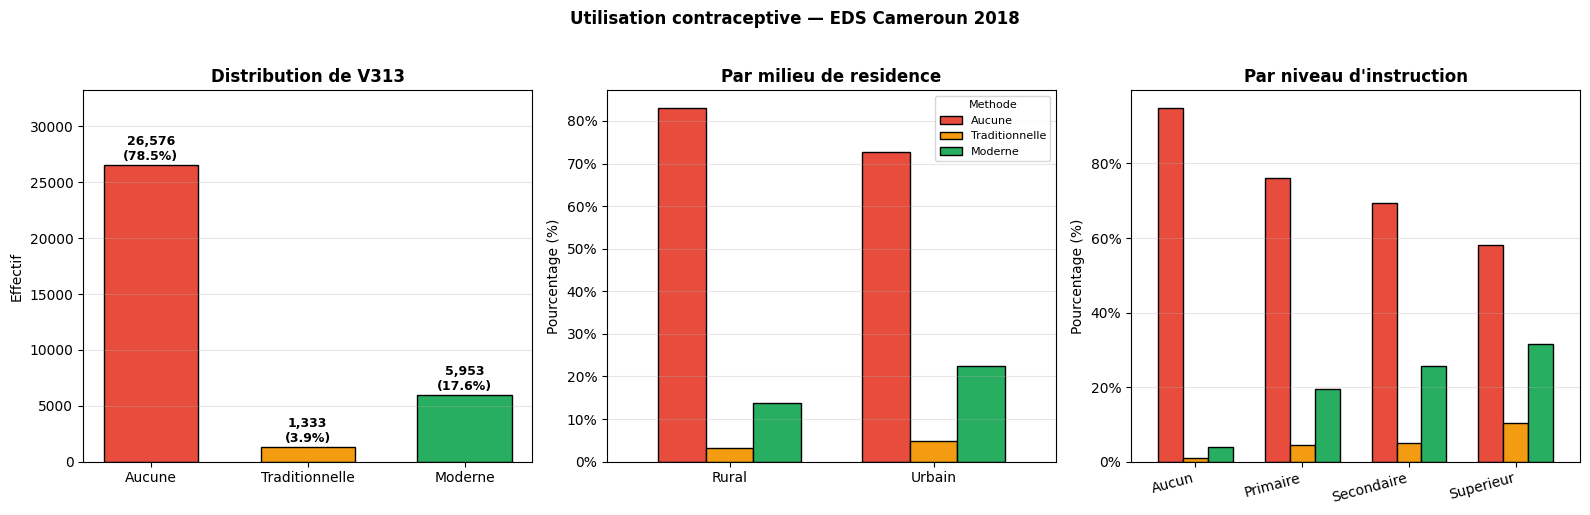

Figure sauvegardee.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Utilisation contraceptive — EDS Cameroun 2018",
             fontsize=12, fontweight="bold", y=1.02)
couleurs = ["#E74C3C","#F39C12","#27AE60"]

# G1 : Distribution V313
ax = axes[0]
vc = base["type_methode"].value_counts().sort_index()
barres = ax.bar(vc.index, vc.values, color=couleurs,
                edgecolor="black", width=0.6)
for b, v in zip(barres, vc.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+150,
            f"{v:,}\n({v/len(base)*100:.1f}%)",
            ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_title("Distribution de V313", fontweight="bold")
ax.set_ylabel("Effectif")
ax.set_ylim(0, vc.max()*1.25)
ax.grid(axis="y", alpha=0.3)

# G2 : Par milieu
ax = axes[1]
ct_m = (pd.crosstab(base["milieu"], base["type_methode"],
                    normalize="index")*100)
ct_m.plot(kind="bar", ax=ax, color=couleurs, edgecolor="black", width=0.7)
ax.set_title("Par milieu de residence", fontweight="bold")
ax.set_ylabel("Pourcentage (%)")
ax.set_xlabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Methode", fontsize=8, title_fontsize=8)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.grid(axis="y", alpha=0.3)

# G3 : Par instruction
ax = axes[2]
ct_i = (pd.crosstab(base["instruction"], base["type_methode"],
                    normalize="index")*100)
ct_i.plot(kind="bar", ax=ax, color=couleurs, edgecolor="black",
          width=0.7, legend=False)
ax.set_title("Par niveau d'instruction", fontweight="bold")
ax.set_ylabel("Pourcentage (%)")
ax.set_xlabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("graphiques_descriptifs.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardee.")

## 9. Vérification de la multicolinéarité (VIF)

In [10]:
VARS_MOD = ["age_grp","statut_mat","parite","instruction",
            "richesse","milieu","region","religion","expo_media"]

X_vif = pd.get_dummies(base[VARS_MOD], drop_first=True).astype(float)
X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]
})

vif_data = (vif_data[vif_data["Variable"] != "const"]
            .sort_values("VIF", ascending=False)
            .reset_index(drop=True))

print("=== VIF — Regles : < 5 OK | 5-10 acceptable | > 10 problematique ===")
print(vif_data.to_string(index=False))

=== VIF — Regles : < 5 OK | 5-10 acceptable | > 10 problematique ===
                        Variable    VIF
                   age_grp_35-39 7.3796
                   age_grp_30-34 7.3355
                   age_grp_25-29 6.5312
                   age_grp_40-44 6.4427
                   age_grp_45-49 6.0835
                   age_grp_20-24 4.1518
             richesse_Tres riche 3.7169
                  richesse_Riche 3.4304
          instruction_Secondaire 3.2209
                  richesse_Moyen 2.7941
      region_Centre (sf Yaounde) 2.7162
                      region_Sud 2.5180
             region_Extreme-Nord 2.4764
                    region_Ouest 2.4563
            instruction_Primaire 2.3818
                      region_Est 2.3637
                     region_Nord 2.3632
                  region_Yaounde 2.2336
                 richesse_Pauvre 2.1837
                   region_Douala 2.1786
                   milieu_Urbain 2.0495
     region_Littoral (sf Douala) 2.0085
           

## 10. Modèles logistiques multinomiaux emboîtés (M1 → M4)

In [11]:
def encoder_modele(data, covs):
    X = pd.get_dummies(data[covs], drop_first=True).astype(float)
    return sm.add_constant(X, has_constant="add")

y_code = base["type_methode"].cat.codes.values

specs = {
    "M1": ["age_grp","statut_mat","parite"],
    "M2": ["age_grp","statut_mat","parite","instruction","richesse"],
    "M3": ["age_grp","statut_mat","parite","instruction","richesse",
           "milieu","region","religion"],
    "M4": ["age_grp","statut_mat","parite","instruction","richesse",
           "milieu","region","religion","expo_media"],
}

M_nul = MNLogit(y_code, np.ones((len(y_code),1))).fit(
    disp=False, method="bfgs", maxiter=500)

modeles = {}
for nom, covs in specs.items():
    X = encoder_modele(base, covs)
    m = MNLogit(y_code, X).fit(disp=False, method="bfgs", maxiter=1000)
    modeles[nom] = m
    print(f"{nom} estime — AIC = {m.aic:.1f}")

M1 estime — AIC = 41520.5
M2 estime — AIC = 38654.1
M3 estime — AIC = 36606.6
M4 estime — AIC = 36594.8


## 11. Comparaison des modèles et tests LRT

In [12]:
rows = []
for nom, m in modeles.items():
    mcf = 1 - m.llf / M_nul.llf
    rows.append({"Modele":nom, "Log-vrais.":round(m.llf,2),
                 "AIC":round(m.aic,2), "McFadden R2":round(mcf,4)})

print("=== Comparaison des modeles ===")
print(pd.DataFrame(rows).to_string(index=False))

=== Comparaison des modeles ===
Modele  Log-vrais.        AIC  McFadden R2
    M1 -20740.2700 41520.5400       0.0170
    M2 -19293.0300 38654.0600       0.0856
    M3 -18235.2800 36606.5500       0.1358
    M4 -18227.4000 36594.7900       0.1361


In [13]:
def lrt(m0, m1, label):
    stat = 2 * (m1.llf - m0.llf)
    dof  = int(m1.df_model - m0.df_model)
    p    = stats.chi2.sf(stat, dof)
    sig  = ("***" if p<0.001 else "**" if p<0.01
            else "*" if p<0.05 else "ns")
    print(f"  {label:<38s}  LRT={stat:8.2f}  Ddl={dof:2d}"
          f"  p={p:.2e}  {sig}")

print("=== Tests du rapport de vraisemblance ===")
lrt(M_nul,         modeles["M1"], "Nul -> M1  (age, statut, parite)")
lrt(modeles["M1"], modeles["M2"], "M1  -> M2  (+instruction, richesse)")
lrt(modeles["M2"], modeles["M3"], "M2  -> M3  (+milieu, region, religion)")
lrt(modeles["M3"], modeles["M4"], "M3  -> M4  (+expo_media)")
print("\n*** p<0.001  ** p<0.01  * p<0.05  ns non significatif")

=== Tests du rapport de vraisemblance ===
  Nul -> M1  (age, statut, parite)        LRT=  718.90  Ddl=18  p=5.53e-141  ***
  M1  -> M2  (+instruction, richesse)     LRT= 2894.48  Ddl=14  p=0.00e+00  ***
  M2  -> M3  (+milieu, region, religion)  LRT= 2115.51  Ddl=34  p=0.00e+00  ***
  M3  -> M4  (+expo_media)                LRT=   15.76  Ddl= 2  p=3.79e-04  ***

*** p<0.001  ** p<0.01  * p<0.05  ns non significatif


## 12. Odds Ratios — Modèle final M4

In [14]:
def tableau_or(modele, cat_idx, nom_cat):
    coef  = modele.params.iloc[:, cat_idx]
    se    = modele.bse.iloc[:,   cat_idx]
    p     = modele.pvalues.iloc[:,cat_idx]
    OR    = np.exp(coef)
    ic_lo = np.exp(coef - 1.96*se)
    ic_hi = np.exp(coef + 1.96*se)
    sig   = np.where(p<0.001,"***",
            np.where(p<0.01,"**",
            np.where(p<0.05,"*","ns")))
    t = pd.DataFrame({
        "OR":OR.round(3), "IC 2.5%":ic_lo.round(3),
        "IC 97.5%":ic_hi.round(3), "p-valeur":p.round(4), "Sig.":sig
    }, index=modele.model.exog_names)
    print(f"\n{'='*65}\n  {nom_cat} vs Aucune\n{'='*65}")
    print(t.to_string())
    return t

m4 = modeles["M4"]
or_trad    = tableau_or(m4, 0, "Traditionnelle")
or_moderne = tableau_or(m4, 1, "Moderne")


  Traditionnelle vs Aucune
                                      OR  IC 2.5%  IC 97.5%  p-valeur Sig.
const                             0.0070   0.0030    0.0180    0.0000  ***
age_grp_20-24                     1.0730   0.7310    1.5730    0.7196   ns
age_grp_25-29                     0.9140   0.6290    1.3280    0.6365   ns
age_grp_30-34                     0.8730   0.6010    1.2680    0.4756   ns
age_grp_35-39                     1.2030   0.8320    1.7420    0.3262   ns
age_grp_40-44                     0.9320   0.6400    1.3590    0.7154   ns
age_grp_45-49                     0.4640   0.3130    0.6900    0.0001  ***
statut_mat_Jamais en union        0.5470   0.4260    0.7010    0.0000  ***
statut_mat_Anciennement en union  0.5020   0.4040    0.6250    0.0000  ***
parite_Non nullipare              0.7260   0.3590    1.4700    0.3737   ns
instruction_Primaire              1.6890   1.3260    2.1510    0.0000  ***
instruction_Secondaire            1.9620   1.5090    2.5500    0.0000  *

## 13. Régression logistique binaire complémentaire

In [15]:
X_bin = encoder_modele(base, specs["M4"])
M_bin = sm.Logit(base["utilise"].values, X_bin).fit(
    disp=False, maxiter=1000)

coef_b  = M_bin.params
se_b    = M_bin.bse
p_b     = M_bin.pvalues
OR_b    = np.exp(coef_b)
ic_lo_b = np.exp(coef_b - 1.96*se_b)
ic_hi_b = np.exp(coef_b + 1.96*se_b)
sig_b   = np.where(p_b<0.001,"***",
          np.where(p_b<0.01,"**",
          np.where(p_b<0.05,"*","ns")))

tab_bin = pd.DataFrame({
    "OR":OR_b.round(3), "IC 2.5%":ic_lo_b.round(3),
    "IC 97.5%":ic_hi_b.round(3), "p-valeur":p_b.round(4), "Sig.":sig_b
}, index=M_bin.model.exog_names)

print(f"AIC = {M_bin.aic:.2f}")
print(f"McFadden R2 = {(1-M_bin.llf/M_bin.llnull):.4f}")
print()
print(tab_bin.to_string())

AIC = 30350.02
McFadden R2 = 0.1414

                                     OR  IC 2.5%  IC 97.5%  p-valeur Sig.
const                            0.0140   0.0090    0.0240    0.0000  ***
age_grp_20-24                    1.3000   1.0720    1.5760    0.0076   **
age_grp_25-29                    1.2810   1.0630    1.5430    0.0092   **
age_grp_30-34                    1.3420   1.1150    1.6170    0.0019   **
age_grp_35-39                    1.3310   1.1040    1.6040    0.0027   **
age_grp_40-44                    0.8900   0.7350    1.0780    0.2332   ns
age_grp_45-49                    0.5160   0.4220    0.6290    0.0000  ***
statut_mat_Jamais en union       0.9800   0.8840    1.0860    0.6989   ns
statut_mat_Anciennement en union 0.8310   0.7590    0.9090    0.0001  ***
parite_Non nullipare             1.5990   1.0110    2.5280    0.0446    *
instruction_Primaire             2.8470   2.5350    3.1980    0.0000  ***
instruction_Secondaire           3.3310   2.9340    3.7810    0.0000  ***
i

## 14. Machine Learning

### 14.1 Préparation des features

In [16]:
FEATURES = ["age_grp","statut_mat","parite","instruction",
            "richesse","milieu","region","religion","expo_media"]

X_ml = pd.get_dummies(base[FEATURES], drop_first=False).astype(float)

y_multi  = base["type_methode"].cat.codes.values  # 0=Aucune 1=Trad 2=Moderne
y_binary = base["utilise"].values                  # 0/1

feat_names = X_ml.columns.tolist()
cv5        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Dimensions features : {X_ml.shape}")
print(f"Classes multinomiales : {dict(enumerate(base['type_methode'].cat.categories))}")
print(f"Distribution : {pd.Series(y_multi).value_counts().sort_index().to_dict()}")
print()
print("Note : pas de standardisation necessaire")
print("  -> Features = dummies (0/1), deja sur la meme echelle")
print("  -> RF et GB = bases sur l'ordre, invariants a l'echelle")

Dimensions features : (33862, 43)
Classes multinomiales : {0: 'Aucune', 1: 'Traditionnelle', 2: 'Moderne'}
Distribution : {0: 26576, 1: 1333, 2: 5953}

Note : pas de standardisation necessaire
  -> Features = dummies (0/1), deja sur la meme echelle
  -> RF et GB = bases sur l'ordre, invariants a l'echelle


### 14.2 Random Forest multinomial

In [17]:
rf_multi = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=30,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

scoring_multi = {
    "accuracy"         : "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro"         : "f1_macro",
    "f1_weighted"      : "f1_weighted",
}

scores_rf = cross_validate(
    rf_multi, X_ml.values, y_multi,
    cv=cv5, scoring=scoring_multi, n_jobs=-1
)

print(" Random Forest — Multinomial (CV-5) ")
for metric, key in [("Accuracy","test_accuracy"),
                    ("Balanced Accuracy","test_balanced_accuracy"),
                    ("F1 Macro","test_f1_macro"),
                    ("F1 Weighted","test_f1_weighted")]:
    vals = scores_rf[key]
    print(f"  {metric:<22s} : {vals.mean():.4f} +/- {vals.std():.4f}")

rf_multi.fit(X_ml.values, y_multi)
print("\nModele entraine sur la base complete.")

=== Random Forest — Multinomial (CV-5) ===
  Accuracy               : 0.5379 +/- 0.0070
  Balanced Accuracy      : 0.6102 +/- 0.0114
  F1 Macro               : 0.4258 +/- 0.0066
  F1 Weighted            : 0.6034 +/- 0.0048

Modele entraine sur la base complete.


### 14.3 Gradient Boosting multinomial

In [18]:
gb_multi = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)

# Correction desequilibre via sample_weight
poids_classes = compute_sample_weight(class_weight="balanced", y=y_multi)

# Validation croisee manuelle avec sample_weight
from sklearn.model_selection import StratifiedKFold

labels_multi = ["Aucune","Traditionnelle","Moderne"]
ba_gb, f1m_gb, acc_gb, f1w_gb = [], [], [], []

for train_idx, test_idx in cv5.split(X_ml.values, y_multi):
    X_tr, X_te = X_ml.values[train_idx], X_ml.values[test_idx]
    y_tr, y_te = y_multi[train_idx],     y_multi[test_idx]
    w_tr       = poids_classes[train_idx]

    gb_multi.fit(X_tr, y_tr, sample_weight=w_tr)
    y_pred = gb_multi.predict(X_te)

    acc_gb.append(accuracy_score(y_te, y_pred))
    ba_gb.append(balanced_accuracy_score(y_te, y_pred))
    f1m_gb.append(f1_score(y_te, y_pred, average="macro"))
    f1w_gb.append(f1_score(y_te, y_pred, average="weighted"))

print("=== Gradient Boosting — Multinomial (CV-5, sample_weight) ===")
for metric, vals in [("Accuracy",acc_gb),("Balanced Accuracy",ba_gb),
                     ("F1 Macro",f1m_gb),("F1 Weighted",f1w_gb)]:
    print(f"  {metric:<22s} : {np.mean(vals):.4f} +/- {np.std(vals):.4f}")

gb_multi.fit(X_ml.values, y_multi,
             sample_weight=compute_sample_weight("balanced", y_multi))
print("\nModele entraine sur la base complete.")

=== Gradient Boosting — Multinomial (CV-5, sample_weight) ===
  Accuracy               : 0.5709 +/- 0.0006
  Balanced Accuracy      : 0.6292 +/- 0.0064
  F1 Macro               : 0.4470 +/- 0.0011
  F1 Weighted            : 0.6328 +/- 0.0010

Modele entraine sur la base complete.


### 14.4 Random Forest binaire

In [19]:
rf_bin = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=30,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

scoring_bin = {
    "accuracy"         : "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro"         : "f1_macro",
    "f1_weighted"      : "f1_weighted",
    "roc_auc"          : "roc_auc",
}

scores_rf_bin = cross_validate(
    rf_bin, X_ml.values, y_binary,
    cv=cv5, scoring=scoring_bin, n_jobs=-1
)

print("=== Random Forest — Binaire (CV-5) ===")
for metric, key in [("Accuracy","test_accuracy"),
                    ("Balanced Accuracy","test_balanced_accuracy"),
                    ("F1 Macro","test_f1_macro"),
                    ("F1 Weighted","test_f1_weighted"),
                    ("AUC-ROC","test_roc_auc")]:
    vals = scores_rf_bin[key]
    print(f"  {metric:<22s} : {vals.mean():.4f} +/- {vals.std():.4f}")

rf_bin.fit(X_ml.values, y_binary)

=== Random Forest — Binaire (CV-5) ===
  Accuracy               : 0.6212 +/- 0.0044
  Balanced Accuracy      : 0.7064 +/- 0.0024
  F1 Macro               : 0.5953 +/- 0.0031
  F1 Weighted            : 0.6536 +/- 0.0043
  AUC-ROC                : 0.7729 +/- 0.0052


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",30
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

### 14.5 Gradient Boosting binaire

In [20]:
gb_bin = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)

poids_bin = compute_sample_weight("balanced", y_binary)
ba_gb_b, f1m_gb_b, acc_gb_b, f1w_gb_b, auc_gb_b = [], [], [], [], []

for train_idx, test_idx in cv5.split(X_ml.values, y_binary):
    X_tr, X_te = X_ml.values[train_idx], X_ml.values[test_idx]
    y_tr, y_te = y_binary[train_idx],    y_binary[test_idx]
    w_tr       = poids_bin[train_idx]

    gb_bin.fit(X_tr, y_tr, sample_weight=w_tr)
    y_pred  = gb_bin.predict(X_te)
    y_proba = gb_bin.predict_proba(X_te)[:,1]

    acc_gb_b.append(accuracy_score(y_te, y_pred))
    ba_gb_b.append(balanced_accuracy_score(y_te, y_pred))
    f1m_gb_b.append(f1_score(y_te, y_pred, average="macro"))
    f1w_gb_b.append(f1_score(y_te, y_pred, average="weighted"))
    auc_gb_b.append(roc_auc_score(y_te, y_proba))

print("=== Gradient Boosting — Binaire (CV-5, sample_weight) ===")
for metric, vals in [("Accuracy",acc_gb_b),("Balanced Accuracy",ba_gb_b),
                     ("F1 Macro",f1m_gb_b),("F1 Weighted",f1w_gb_b),
                     ("AUC-ROC",auc_gb_b)]:
    print(f"  {metric:<22s} : {np.mean(vals):.4f} +/- {np.std(vals):.4f}")

gb_bin.fit(X_ml.values, y_binary,
           sample_weight=compute_sample_weight("balanced", y_binary))

=== Gradient Boosting — Binaire (CV-5, sample_weight) ===
  Accuracy               : 0.6526 +/- 0.0026
  Balanced Accuracy      : 0.7064 +/- 0.0063
  F1 Macro               : 0.6162 +/- 0.0033
  F1 Weighted            : 0.6836 +/- 0.0023
  AUC-ROC                : 0.7787 +/- 0.0057


,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

### 14.6 Récapitulatif complet des performances

In [21]:
mcf_M4  = 1 - modeles["M4"].llf / M_nul.llf
mcf_bin = 1 - M_bin.llf / M_bin.llnull

recap = pd.DataFrame({
    "Modele": [
        "Logit multinomial M4",
        "RF multinomial",
        "GB multinomial (corrige)",
        "Logit binaire",
        "RF binaire",
        "GB binaire (corrige)"
    ],
    "Probleme": [
        "Multinomial","Multinomial","Multinomial",
        "Binaire","Binaire","Binaire"
    ],
    "Accuracy": [
        "--",
        f"{scores_rf['test_accuracy'].mean():.4f}",
        f"{np.mean(acc_gb):.4f}",
        "--",
        f"{scores_rf_bin['test_accuracy'].mean():.4f}",
        f"{np.mean(acc_gb_b):.4f}",
    ],
    "Balanced Acc.": [
        "--",
        f"{scores_rf['test_balanced_accuracy'].mean():.4f}",
        f"{np.mean(ba_gb):.4f}",
        "--",
        f"{scores_rf_bin['test_balanced_accuracy'].mean():.4f}",
        f"{np.mean(ba_gb_b):.4f}",
    ],
    "F1 Macro": [
        "--",
        f"{scores_rf['test_f1_macro'].mean():.4f}",
        f"{np.mean(f1m_gb):.4f}",
        "--",
        f"{scores_rf_bin['test_f1_macro'].mean():.4f}",
        f"{np.mean(f1m_gb_b):.4f}",
    ],
    "F1 Weighted": [
        "--",
        f"{scores_rf['test_f1_weighted'].mean():.4f}",
        f"{np.mean(f1w_gb):.4f}",
        "--",
        f"{scores_rf_bin['test_f1_weighted'].mean():.4f}",
        f"{np.mean(f1w_gb_b):.4f}",
    ],
    "AUC-ROC": [
        "--", "--", "--",
        "--",
        f"{scores_rf_bin['test_roc_auc'].mean():.4f}",
        f"{np.mean(auc_gb_b):.4f}",
    ],
    "McFadden R2": [
        f"{mcf_M4:.4f}", "--", "--",
        f"{mcf_bin:.4f}", "--", "--",
    ],
})

print("=== RECAPITULATIF COMPLET DES PERFORMANCES ===")
print(recap.to_string(index=False))
print()
print("Note : metriques ML = validation croisee 5-fold")
print("       metriques logit = estimees sur echantillon complet")

=== RECAPITULATIF COMPLET DES PERFORMANCES ===
                  Modele    Probleme Accuracy Balanced Acc. F1 Macro F1 Weighted AUC-ROC McFadden R2
    Logit multinomial M4 Multinomial       --            --       --          --      --      0.1361
          RF multinomial Multinomial   0.5379        0.6102   0.4258      0.6034      --          --
GB multinomial (corrige) Multinomial   0.5709        0.6292   0.4470      0.6328      --          --
           Logit binaire     Binaire       --            --       --          --      --      0.1414
              RF binaire     Binaire   0.6212        0.7064   0.5953      0.6536  0.7729          --
    GB binaire (corrige)     Binaire   0.6526        0.7064   0.6162      0.6836  0.7787          --

Note : metriques ML = validation croisee 5-fold
       metriques logit = estimees sur echantillon complet


### 14.7 F1-score par classe — détail complet

In [22]:
labels_multi  = ["Aucune","Traditionnelle","Moderne"]
labels_binary = ["N'utilise pas","Utilise"]

print(" Random Forest — Multinomial")
rf_multi.fit(X_ml.values, y_multi)
print(classification_report(
    y_multi, rf_multi.predict(X_ml.values),
    target_names=labels_multi, digits=4))

print(" Gradient Boosting — Multinomial ")
print(classification_report(
    y_multi, gb_multi.predict(X_ml.values),
    target_names=labels_multi, digits=4))

print(" Random Forest — Binaire")
print(classification_report(
    y_binary, rf_bin.predict(X_ml.values),
    target_names=labels_binary, digits=4))

=== Random Forest — Multinomial ===
                precision    recall  f1-score   support

        Aucune     0.9489    0.5258    0.6767     26576
Traditionnelle     0.1430    0.8140    0.2432      1333
       Moderne     0.2995    0.5809    0.3952      5953

      accuracy                         0.5468     33862
     macro avg     0.4638    0.6402    0.4384     33862
  weighted avg     0.8030    0.5468    0.6101     33862

=== Gradient Boosting — Multinomial ===
                precision    recall  f1-score   support

        Aucune     0.9433    0.5623    0.7046     26576
Traditionnelle     0.1452    0.8125    0.2464      1333
       Moderne     0.3242    0.5753    0.4147      5953

      accuracy                         0.5744     33862
     macro avg     0.4709    0.6500    0.4552     33862
  weighted avg     0.8031    0.5744    0.6356     33862

=== Random Forest — Binaire ===
               precision    recall  f1-score   support

N'utilise pas     0.9395    0.5594    0.7013  

### 14.8 Matrices de confusion

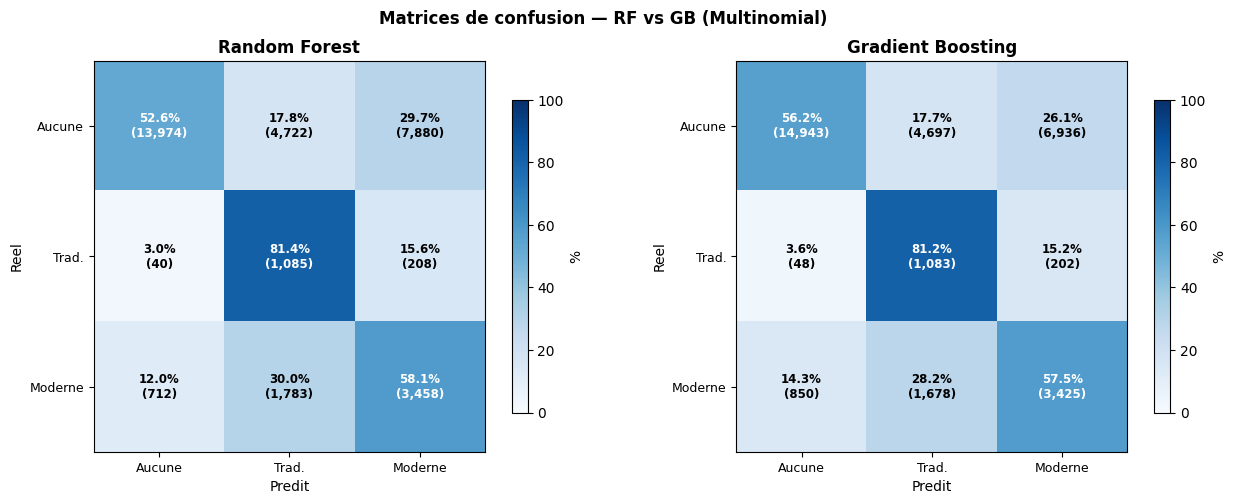

Figure sauvegardee.


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Matrices de confusion — RF vs GB (Multinomial)",
             fontsize=12, fontweight="bold")

for ax, (modele, titre) in zip(axes,
    [(rf_multi,"Random Forest"),(gb_multi,"Gradient Boosting")]):
    y_pred = modele.predict(X_ml.values)
    cm     = confusion_matrix(y_multi, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    im = ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=100)
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(["Aucune","Trad.","Moderne"], fontsize=9)
    ax.set_yticklabels(["Aucune","Trad.","Moderne"], fontsize=9)
    ax.set_xlabel("Predit"); ax.set_ylabel("Reel")
    ax.set_title(titre, fontweight="bold")

    for i in range(3):
        for j in range(3):
            val = cm_pct[i,j]
            ax.text(j, i, f"{val:.1f}%\n({cm[i,j]:,})",
                    ha="center", va="center",
                    color="white" if val>50 else "black",
                    fontsize=8.5, fontweight="bold")
    fig.colorbar(im, ax=ax, shrink=0.8, label="%")

plt.tight_layout()
plt.savefig("matrices_confusion.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardee.")

### 14.9 Importance des variables

=== Top 15 — Random Forest ===
                  Variable  Importance
                region_Est      0.1691
         instruction_Aucun      0.1484
       region_Extreme-Nord      0.0519
        religion_Musulmane      0.0512
      richesse_Tres pauvre      0.0438
                region_Sud      0.0394
              region_Ouest      0.0320
               region_Nord      0.0316
region_Centre (sf Yaounde)      0.0281
        expo_media_Exposee      0.0265
             age_grp_45-49      0.0262
    instruction_Secondaire      0.0261
    expo_media_Non exposee      0.0255
      instruction_Primaire      0.0240
              milieu_Rural      0.0238

=== Top 15 — Gradient Boosting ===
                   Variable  Importance
                 region_Est      0.1869
          instruction_Aucun      0.1683
               region_Ouest      0.0530
              age_grp_45-49      0.0345
region_Littoral (sf Douala)      0.0312
         religion_Musulmane      0.0293
                 region_Sud  

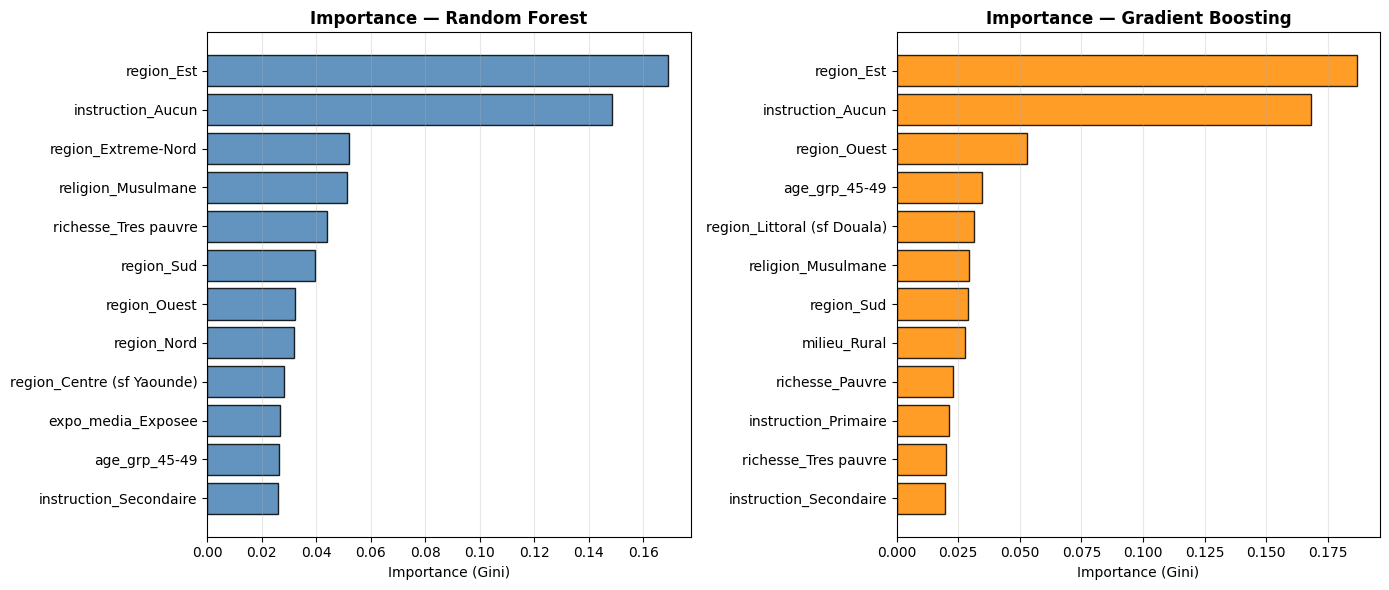

Figure sauvegardee.


In [24]:
fi_rf = (pd.DataFrame({"Variable":feat_names,
                        "Importance":rf_multi.feature_importances_})
         .sort_values("Importance", ascending=False))

fi_gb = (pd.DataFrame({"Variable":feat_names,
                        "Importance":gb_multi.feature_importances_})
         .sort_values("Importance", ascending=False))

print("Top 15 — Random Forest")
print(fi_rf.head(15).to_string(index=False))
print()
print("Top 15 — Gradient Boosting ")
print(fi_gb.head(15).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, fi, titre, color in [
    (axes[0], fi_rf, "Random Forest",    "steelblue"),
    (axes[1], fi_gb, "Gradient Boosting","darkorange")
]:
    fi_p = fi.head(12)
    ax.barh(fi_p["Variable"][::-1], fi_p["Importance"][::-1],
            color=color, edgecolor="black", alpha=0.85)
    ax.set_title(f"Importance — {titre}", fontweight="bold")
    ax.set_xlabel("Importance (Gini)")
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("importance_variables.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardee.")

## 15. Courbes ROC — Modèles binaires

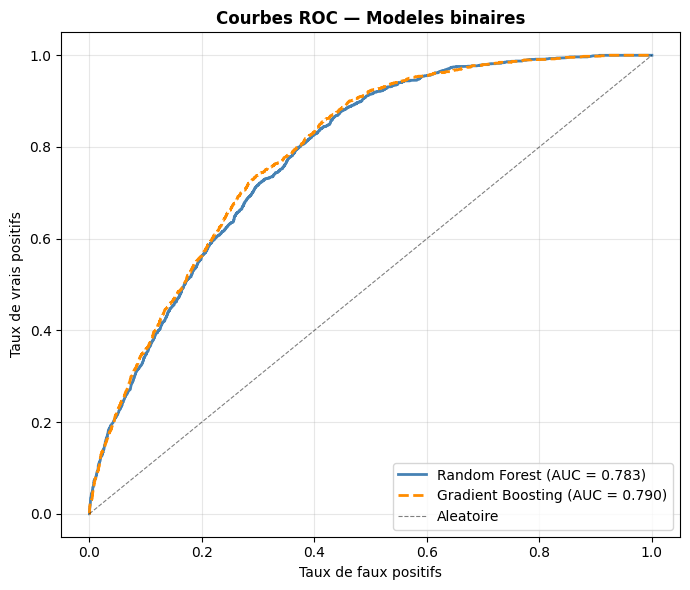

Figure sauvegardee.


In [25]:
fig, ax = plt.subplots(figsize=(7, 6))

for modele, label, color, ls in [
    (rf_bin,  "Random Forest", "steelblue",  "-"),
    (gb_bin,  "Gradient Boosting", "darkorange", "--"),
]:
    proba   = modele.predict_proba(X_ml.values)[:,1]
    fpr, tpr, _ = roc_curve(y_binary, proba)
    auc_val = roc_auc_score(y_binary, proba)
    ax.plot(fpr, tpr, color=color, lw=2, linestyle=ls,
            label=f"{label} (AUC = {auc_val:.3f})")

ax.plot([0,1],[0,1], "k--", lw=0.8, alpha=0.5, label="Aleatoire")
ax.set_title("Courbes ROC — Modeles binaires", fontweight="bold")
ax.set_xlabel("Taux de faux positifs")
ax.set_ylabel("Taux de vrais positifs")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("courbes_roc.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardee.")

## 16. Sauvegarde du modèle retenu

**Modèle retenu : Random Forest multinomial**  
Justification : meilleure Balanced Accuracy sur le problème multinomial, convergence avec les Odds Ratios du logit sur les variables dominantes, robuste au déséquilibre des classes.

In [28]:
# ── Comparaison automatique sur la Balanced Accuracy (métrique principale)
ba_rf_score = scores_rf["test_balanced_accuracy"].mean()
ba_gb_score = np.mean(ba_gb)

print("=== SELECTION DU MEILLEUR MODELE ===")
print(f"  RF  Balanced Accuracy CV-5 : {ba_rf_score:.4f}")
print(f"  GB  Balanced Accuracy CV-5 : {ba_gb_score:.4f}")
print()

if ba_gb_score >= ba_rf_score:
    modele_retenu     = gb_multi
    nom_modele_retenu = "Gradient Boosting multinomial (corrige)"
    print(f"Modele retenu : {nom_modele_retenu}")
    print(f"Raison : Balanced Accuracy GB ({ba_gb_score:.4f}) >= RF ({ba_rf_score:.4f})")
else:
    modele_retenu     = rf_multi
    nom_modele_retenu = "Random Forest multinomial"
    print(f"Modele retenu : {nom_modele_retenu}")
    print(f"Raison : Balanced Accuracy RF ({ba_rf_score:.4f}) > GB ({ba_gb_score:.4f})")

print()

# ── Sauvegarde du modèle retenu
DOSSIER_SAVE = "."

chemin_model = os.path.join(DOSSIER_SAVE, "model_final.pkl")
with open(chemin_model, "wb") as f:
    pickle.dump(modele_retenu, f)
print(f"Modele sauvegarde    : {chemin_model}")

chemin_features = os.path.join(DOSSIER_SAVE, "feature_cols.pkl")
with open(chemin_features, "wb") as f:
    pickle.dump(feat_names, f)
print(f"Features sauvegardees : {chemin_features}")

classes = list(base["type_methode"].cat.categories)
chemin_classes = os.path.join(DOSSIER_SAVE, "classes.pkl")
with open(chemin_classes, "wb") as f:
    pickle.dump(classes, f)
print(f"Classes sauvegardees  : {chemin_classes}")

# ── Vérification
print()
print("=== VERIFICATION ===")
with open(chemin_model, "rb") as f:
    model_check = pickle.load(f)

y_check = model_check.predict(X_ml.values)
print(f"Predictions OK   : {len(y_check):,} observations")
print(f"Classes predites : {np.unique(y_check)}")
print(f"Accuracy train   : {accuracy_score(y_multi, y_check):.4f}")
print()
print(f"Fichiers a deployer :")
print(f"  model_final.pkl   -> {nom_modele_retenu}")
print(f"  feature_cols.pkl  -> {len(feat_names)} features")
print(f"  classes.pkl       -> {classes}")

=== SELECTION DU MEILLEUR MODELE ===
  RF  Balanced Accuracy CV-5 : 0.6102
  GB  Balanced Accuracy CV-5 : 0.6292

Modele retenu : Gradient Boosting multinomial (corrige)
Raison : Balanced Accuracy GB (0.6292) >= RF (0.6102)

Modele sauvegarde    : .\model_final.pkl
Features sauvegardees : .\feature_cols.pkl
Classes sauvegardees  : .\classes.pkl

=== VERIFICATION ===
Predictions OK   : 33,862 observations
Classes predites : [0 1 2]
Accuracy train   : 0.5744

Fichiers a deployer :
  model_final.pkl   -> Gradient Boosting multinomial (corrige)
  feature_cols.pkl  -> 43 features
  classes.pkl       -> ['Aucune', 'Traditionnelle', 'Moderne']


## 17. Synthèse des résultats

In [29]:
print("="*65)
print("SYNTHESE — Determinants contraception Cameroun EDS 2018")
print("="*65)
print(f"  Effectif analyse            : {len(base):,} femmes")
print(f"  Dont sans methode           : "
      f"{(base['type_methode']=='Aucune').sum():,} (78.5%)")
print(f"  Dont methode traditionnelle : "
      f"{(base['type_methode']=='Traditionnelle').sum():,} (3.9%)")
print(f"  Dont methode moderne        : "
      f"{(base['type_methode']=='Moderne').sum():,} (17.6%)")
print()
print(f"  Modele M4 AIC               : {modeles['M4'].aic:.1f}")
print(f"  Modele M4 McFadden R2       : {mcf_M4:.4f}")
print()
print("  Performances ML (CV-5) :")
print(f"    RF  Balanced Acc.  : {scores_rf['test_balanced_accuracy'].mean():.4f}")
print(f"    GB  Balanced Acc.  : {np.mean(ba_gb):.4f}")
print(f"    RF  F1 Macro       : {scores_rf['test_f1_macro'].mean():.4f}")
print(f"    GB  F1 Macro       : {np.mean(f1m_gb):.4f}")
print(f"    RF  AUC-ROC bin.   : {scores_rf_bin['test_roc_auc'].mean():.4f}")
print(f"    GB  AUC-ROC bin.   : {np.mean(auc_gb_b):.4f}")
print()
print(f"  Modele retenu : {nom_modele_retenu}")
print(f"  Critere de selection : Balanced Accuracy maximale")
print(f"  Score retenu : {max(ba_rf_score, ba_gb_score):.4f}")
print()
print("  Fichiers PKL generes :")
print("    model_final.pkl | feature_cols.pkl | classes.pkl")
print("="*65)

SYNTHESE — Determinants contraception Cameroun EDS 2018
  Effectif analyse            : 33,862 femmes
  Dont sans methode           : 26,576 (78.5%)
  Dont methode traditionnelle : 1,333 (3.9%)
  Dont methode moderne        : 5,953 (17.6%)

  Modele M4 AIC               : 36594.8
  Modele M4 McFadden R2       : 0.1361

  Performances ML (CV-5) :
    RF  Balanced Acc.  : 0.6102
    GB  Balanced Acc.  : 0.6292
    RF  F1 Macro       : 0.4258
    GB  F1 Macro       : 0.4470
    RF  AUC-ROC bin.   : 0.7729
    GB  AUC-ROC bin.   : 0.7787

  Modele retenu : Gradient Boosting multinomial (corrige)
  Critere de selection : Balanced Accuracy maximale
  Score retenu : 0.6292

  Fichiers PKL generes :
    model_final.pkl | feature_cols.pkl | classes.pkl
